# Plotting and Calibrating Geoprecision Thermistor chain data

This notebook provides a workflow for plotting and calibrating thermistor chain data from glacier boreholes and calibration experiments. It uses custom modules for data processing and visualization.

## Import required Libraries and Modules

In [1]:
import sys
import os

# Add project root to Python path
project_root = '/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt

# Import custom modules
from processing.process_thermistor_data import *
from calibration.thermistor_calibration import *

In [2]:
# root dir
root_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/"

# set main calibration data dir
cal_dir = root_dir + "thermistor_chains/calibration_data/"

# set chain calibration dir
A551FD_dir = cal_dir + "A551FD/raw/"
A551FE_dir = cal_dir + "A551FE/raw/"
A55200_dir = cal_dir + "A55200/raw/"
A55201_dir = cal_dir + "A55201/raw/"
A55202_dir = cal_dir + "A55202/raw/"
A55203_dir = cal_dir + "A55203/raw/"
A55204_dir = cal_dir + "A55204/raw/"
A55205_dir = cal_dir + "A55205/raw/"

# set maximum measurement depths
A551FE_depth = 45.0 # AH1 -> borehole depth is 50.6m
A55204_depth = 20.3 # AH2
A55205_depth = 18.3 # AH3 -> borehole depth is 58.3m
A551FD_depth = 29.0 # HL1
A55203_depth = 21.5 # HL2 
A55200_depth = 21.5 # HL3
A55201_depth = 38.3 # CH1
A55202_depth = 17.0 # CH2

# generate calibration data objects
A551FE_cal_data = ThermistorData(A551FE_dir + "A551FE_20250729123855.csv",",",A551FE_depth)   
A55204_cal_data = ThermistorData(A55204_dir + "A55204_20250729123756.csv",",",A55204_depth)   
A55205_cal_data = ThermistorData(A55205_dir + "A55205_20250729123810.csv",",",A55205_depth)   
A551FD_cal_data = ThermistorData(A551FD_dir + "A551FD_20250729123824.csv",",",A551FD_depth)
A55203_cal_data = ThermistorData(A55203_dir + "A55203_20250729123726.csv",",",A55203_depth)   
A55200_cal_data = ThermistorData(A55200_dir + "A55200_20250729123642.csv",",",A55200_depth)   
A55201_cal_data = ThermistorData(A55201_dir + "A55201_20250729123655.csv",",",A55201_depth)   
A55202_cal_data = ThermistorData(A55202_dir + "A55202_20250729123712.csv",",",A55202_depth)   


## Load thermistor chain data

In [3]:
# get calibration data for each thermistor chain
A551FD_cal_df = A551FD_cal_data.get_chain_data('28.07.2025 13:30:00','28.07.2025 14:30:00')
A551FE_cal_df = A551FE_cal_data.get_chain_data('28.07.2025 12:00:00','28.07.2025 14:00:00')
A55200_cal_df = A55200_cal_data.get_chain_data('29.07.2025 10:00:00','29.07.2025 13:00:00')
A55201_cal_df = A55201_cal_data.get_chain_data('28.07.2025 09:00:00','28.07.2025 12:00:00')
A55202_cal_df = A55202_cal_data.get_chain_data('28.07.2025 14:00:00','28.07.2025 16:00:00')
A55203_cal_df = A55203_cal_data.get_chain_data('28.07.2025 08:00:00','28.07.2025 10:00:00')
A55204_cal_df = A55204_cal_data.get_chain_data('25.07.2025 12:00:00','25.07.2025 14:00:00')
A55205_cal_df = A55205_cal_data.get_chain_data('25.07.2025 13:00:00','25.07.2025 15:00:00')


In [4]:
A55205_cal_df

,NO,TIME,#1,#2,#3,#4,#5,HK-BAT:V
219,220,2025-07-25 13:00:00,20.512200,20.269500,20.124900,21.081700,21.113700,NaN
220,221,2025-07-25 13:48:40,0.348742,0.286983,0.144036,0.888928,-0.268278,3.331
221,222,2025-07-25 13:49:40,-0.115338,-0.126626,-0.144247,0.239865,-0.217739,NaN
222,223,2025-07-25 13:50:40,-0.124564,-0.129060,-0.152247,0.075645,-0.241742,NaN
223,224,2025-07-25 13:51:40,-0.133029,-0.134014,-0.140436,0.071752,-0.240068,NaN
...,...,...,...,...,...,...,...,...
279,280,2025-07-25 14:47:40,-0.145983,-0.152765,-0.149812,-0.149112,-0.196849,NaN
280,281,2025-07-25 14:48:40,-0.143249,-0.142396,-0.161706,-0.137368,-0.259747,3.330
281,282,2025-07-25 14:49:40,-0.145221,-0.152002,-0.140735,-0.138594,-0.204918,NaN
282,283,2025-07-25 14:50:40,-0.146678,-0.148043,-0.140055,-0.142552,-0.183499,NaN


In [5]:
# calculate zero degree offsets
all_offsets = {
    "A551FD": calculate_chain_zero_degree_offsets(A551FD_cal_df),
    "A551FE": calculate_chain_zero_degree_offsets(A551FE_cal_df),
    "A55200": calculate_chain_zero_degree_offsets(A55200_cal_df),
    "A55201": calculate_chain_zero_degree_offsets(A55201_cal_df),
    "A55202": calculate_chain_zero_degree_offsets(A55202_cal_df),
    "A55203": calculate_chain_zero_degree_offsets(A55203_cal_df),
    "A55204": calculate_chain_zero_degree_offsets(A55204_cal_df),
    "A55205": calculate_chain_zero_degree_offsets(A55205_cal_df),
}

# read high-precision thermometer data
hp_thermometer_dir = cal_dir + "/high_precision_thermometer.csv" # set path to high-precision thermometer data
hp_thermometer_df = pd.read_csv(hp_thermometer_dir, sep=';', header=0, decimal=',')

# apply correction from high-precision thermometer --> gives most accurate temperature of alcohol bath from which the offsets can be calculated
corrected_offsets = {}
for chain, offsets in all_offsets.items():
    bath_temp = hp_thermometer_df.loc[hp_thermometer_df['logger'] == chain, 'average temp'].values[0]
    corrected_offsets[chain] = {k: v - bath_temp for k, v in offsets.items()}

# generate variables holding corrected offsets per chain
A551FE_offsets = corrected_offsets['A551FE'] # AH1
A55204_offsets = corrected_offsets['A55204'] # AH2
A55205_offsets = corrected_offsets['A55205'] # AH3
A551FD_offsets = corrected_offsets['A551FD'] # HL1
A55203_offsets = corrected_offsets['A55203'] # HL2
A55200_offsets = corrected_offsets['A55200'] # HL3
A55201_offsets = corrected_offsets['A55201'] # CH1
A55202_offsets = corrected_offsets['A55202'] # CH2


## Calculate 0-degree offsets
Measurements in 0 degree alcohol bath. The final offsets will be calculated from the bath temperature measured by a high-precision thermometer.

In [6]:
all_offsets

{'A551FD': {'#1': -0.150565,
  '#2': -0.166567,
  '#3': -0.143027,
  '#4': -0.129672,
  '#5': -0.200576,
  '#6': -0.163682,
  '#7': -0.139061,
  '#8': -0.134942,
  '#9': -0.153012,
  '#10': -0.146218},
 'A551FE': {'#1': -0.14236749999999998,
  '#2': -0.303417,
  '#3': -0.141492,
  '#4': -0.00464582,
  '#5': -0.196464,
  '#6': -0.1057035,
  '#7': -0.120152,
  '#8': -0.0582381,
  '#9': -0.1283455,
  '#10': -0.28461800000000004},
 'A55200': {'#1': -0.1008275,
  '#2': -0.0999496,
  '#3': -0.0960516,
  '#4': -0.1142,
  '#5': -0.0907997},
 'A55201': {'#1': -0.15245999999999998,
  '#2': -0.203133,
  '#3': -0.1589445,
  '#4': -0.151594,
  '#5': -0.160092,
  '#6': -0.15281499999999998,
  '#7': -0.215412,
  '#8': -0.13234200000000002,
  '#9': -0.121974,
  '#10': -0.117437},
 'A55202': {'#1': -0.174625,
  '#2': -0.180368,
  '#3': -0.166655,
  '#4': -0.1665335,
  '#5': -0.05686155},
 'A55203': {'#1': -0.110693,
  '#2': -0.109474,
  '#3': -0.111759,
  '#4': -0.14295,
  '#5': -0.111694},
 'A55204': 

In [7]:
corrected_offsets

{'A551FD': {'#1': np.float64(0.009434999999999999),
  '#2': np.float64(-0.0065669999999999895),
  '#3': np.float64(0.016973000000000016),
  '#4': np.float64(0.030327999999999994),
  '#5': np.float64(-0.040576),
  '#6': np.float64(-0.003681999999999991),
  '#7': np.float64(0.020939000000000013),
  '#8': np.float64(0.025057999999999997),
  '#9': np.float64(0.006987999999999994),
  '#10': np.float64(0.013782000000000016)},
 'A551FE': {'#1': np.float64(-0.020367499999999983),
  '#2': np.float64(-0.181417),
  '#3': np.float64(-0.01949200000000001),
  '#4': np.float64(0.11735418),
  '#5': np.float64(-0.074464),
  '#6': np.float64(0.01629649999999999),
  '#7': np.float64(0.0018480000000000024),
  '#8': np.float64(0.0637619),
  '#9': np.float64(-0.006345500000000004),
  '#10': np.float64(-0.16261800000000004)},
 'A55200': {'#1': np.float64(0.027172500000000002),
  '#2': np.float64(0.028050400000000003),
  '#3': np.float64(0.0319484),
  '#4': np.float64(0.013800000000000007),
  '#5': np.float64

## Plot Thermistor Chain Data

In [8]:
# set main icetemp data dir
gp_icetemp_dir = root_dir + "thermistor_chains/temperature_data/"

# set output dir for figures
output_dir = "/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/projects/asses_swiss_gl_therm_regimes/products/figures/icetemp_results/geoprecision/"

# set chain data dir
A551FE_dir = gp_icetemp_dir + "A551FE/raw/" # AH1
A55204_dir = gp_icetemp_dir + "A55204/raw/" # AH2
A55205_dir = gp_icetemp_dir + "A55205/raw/" # AH3
A551FD_dir = gp_icetemp_dir + "A551FD/raw/" # HL1
A55203_dir = gp_icetemp_dir + "A55203/raw/" # HL2
A55200_dir = gp_icetemp_dir + "A55200/raw/" # HL3
A55201_dir = gp_icetemp_dir + "A55201/raw/A55201_20250819105833.csv" # CH1
A55202_dir = gp_icetemp_dir + "A55202/raw/A55202_20250819111557.csv" # CH2

# set path to current depth file
depth_ch1 = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch1.csv"
depth_ch2 = gp_icetemp_dir + "../../thermistor_settings/thermistor_settings_ch2.csv"

# generate chain plotting objects per borehole
CH1 = ThermistorDataPlotter(A55201_dir, ",")
CH2 = ThermistorDataPlotter(A55202_dir, ",")

# generate a thermistor data object
CH1_data = ThermistorData(A55201_dir, ",", depth_ch1)
CH2_data = ThermistorData(A55202_dir, ",", depth_ch2)

In [9]:
CH1_data.get_chain_data('07.08.2025 13:30:00','19.08.2025 13:00:00')
# CH1_data.get_chain_data_with_offsets('07.08.2025 13:30:00','19.08.2025 13:00:00', A55201_offsets)

,NO,TIME,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10,HK-BAT:V
387,388,2025-08-07 14:00:00,-0.105740,-0.118852,-0.218112,-0.067766,0.002446,-0.041006,-0.017227,-0.009452,-0.010216,0.018237,NaN
388,389,2025-08-07 15:00:00,-0.102146,-0.072188,-0.185712,-0.126937,0.002066,-0.038802,-0.016912,-0.007464,-0.012502,0.019978,NaN
389,390,2025-08-07 16:00:00,-0.048410,-0.122049,-0.163136,-0.175422,0.004202,-0.037046,-0.016845,-0.005708,-0.010133,0.020209,NaN
390,391,2025-08-07 17:00:00,-0.053893,-0.442696,-0.282978,-0.179613,0.005345,-0.041088,-0.014013,-0.007547,-0.011425,0.020143,NaN
391,392,2025-08-07 18:00:00,-0.048245,-0.406937,-0.304628,-0.184334,0.006570,-0.037345,-0.014095,-0.007928,-0.010365,0.019679,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,670,2025-08-19 08:00:00,-0.928355,-0.687609,-0.484389,-0.365465,-0.231916,-0.198146,-0.103917,-0.045350,-0.019890,0.026240,NaN
670,671,2025-08-19 09:00:00,-0.928967,-0.686997,-0.485533,-0.363113,-0.232214,-0.195925,-0.106435,-0.041920,-0.018666,0.025544,3.362
671,672,2025-08-19 10:00:00,-0.930722,-0.687907,-0.484688,-0.365398,-0.233126,-0.196075,-0.107795,-0.047255,-0.018448,0.024716,NaN
672,673,2025-08-19 11:00:00,-0.930409,-0.687310,-0.483627,-0.364173,-0.235942,-0.197450,-0.106965,-0.044671,-0.020354,0.023572,NaN


### Time Series

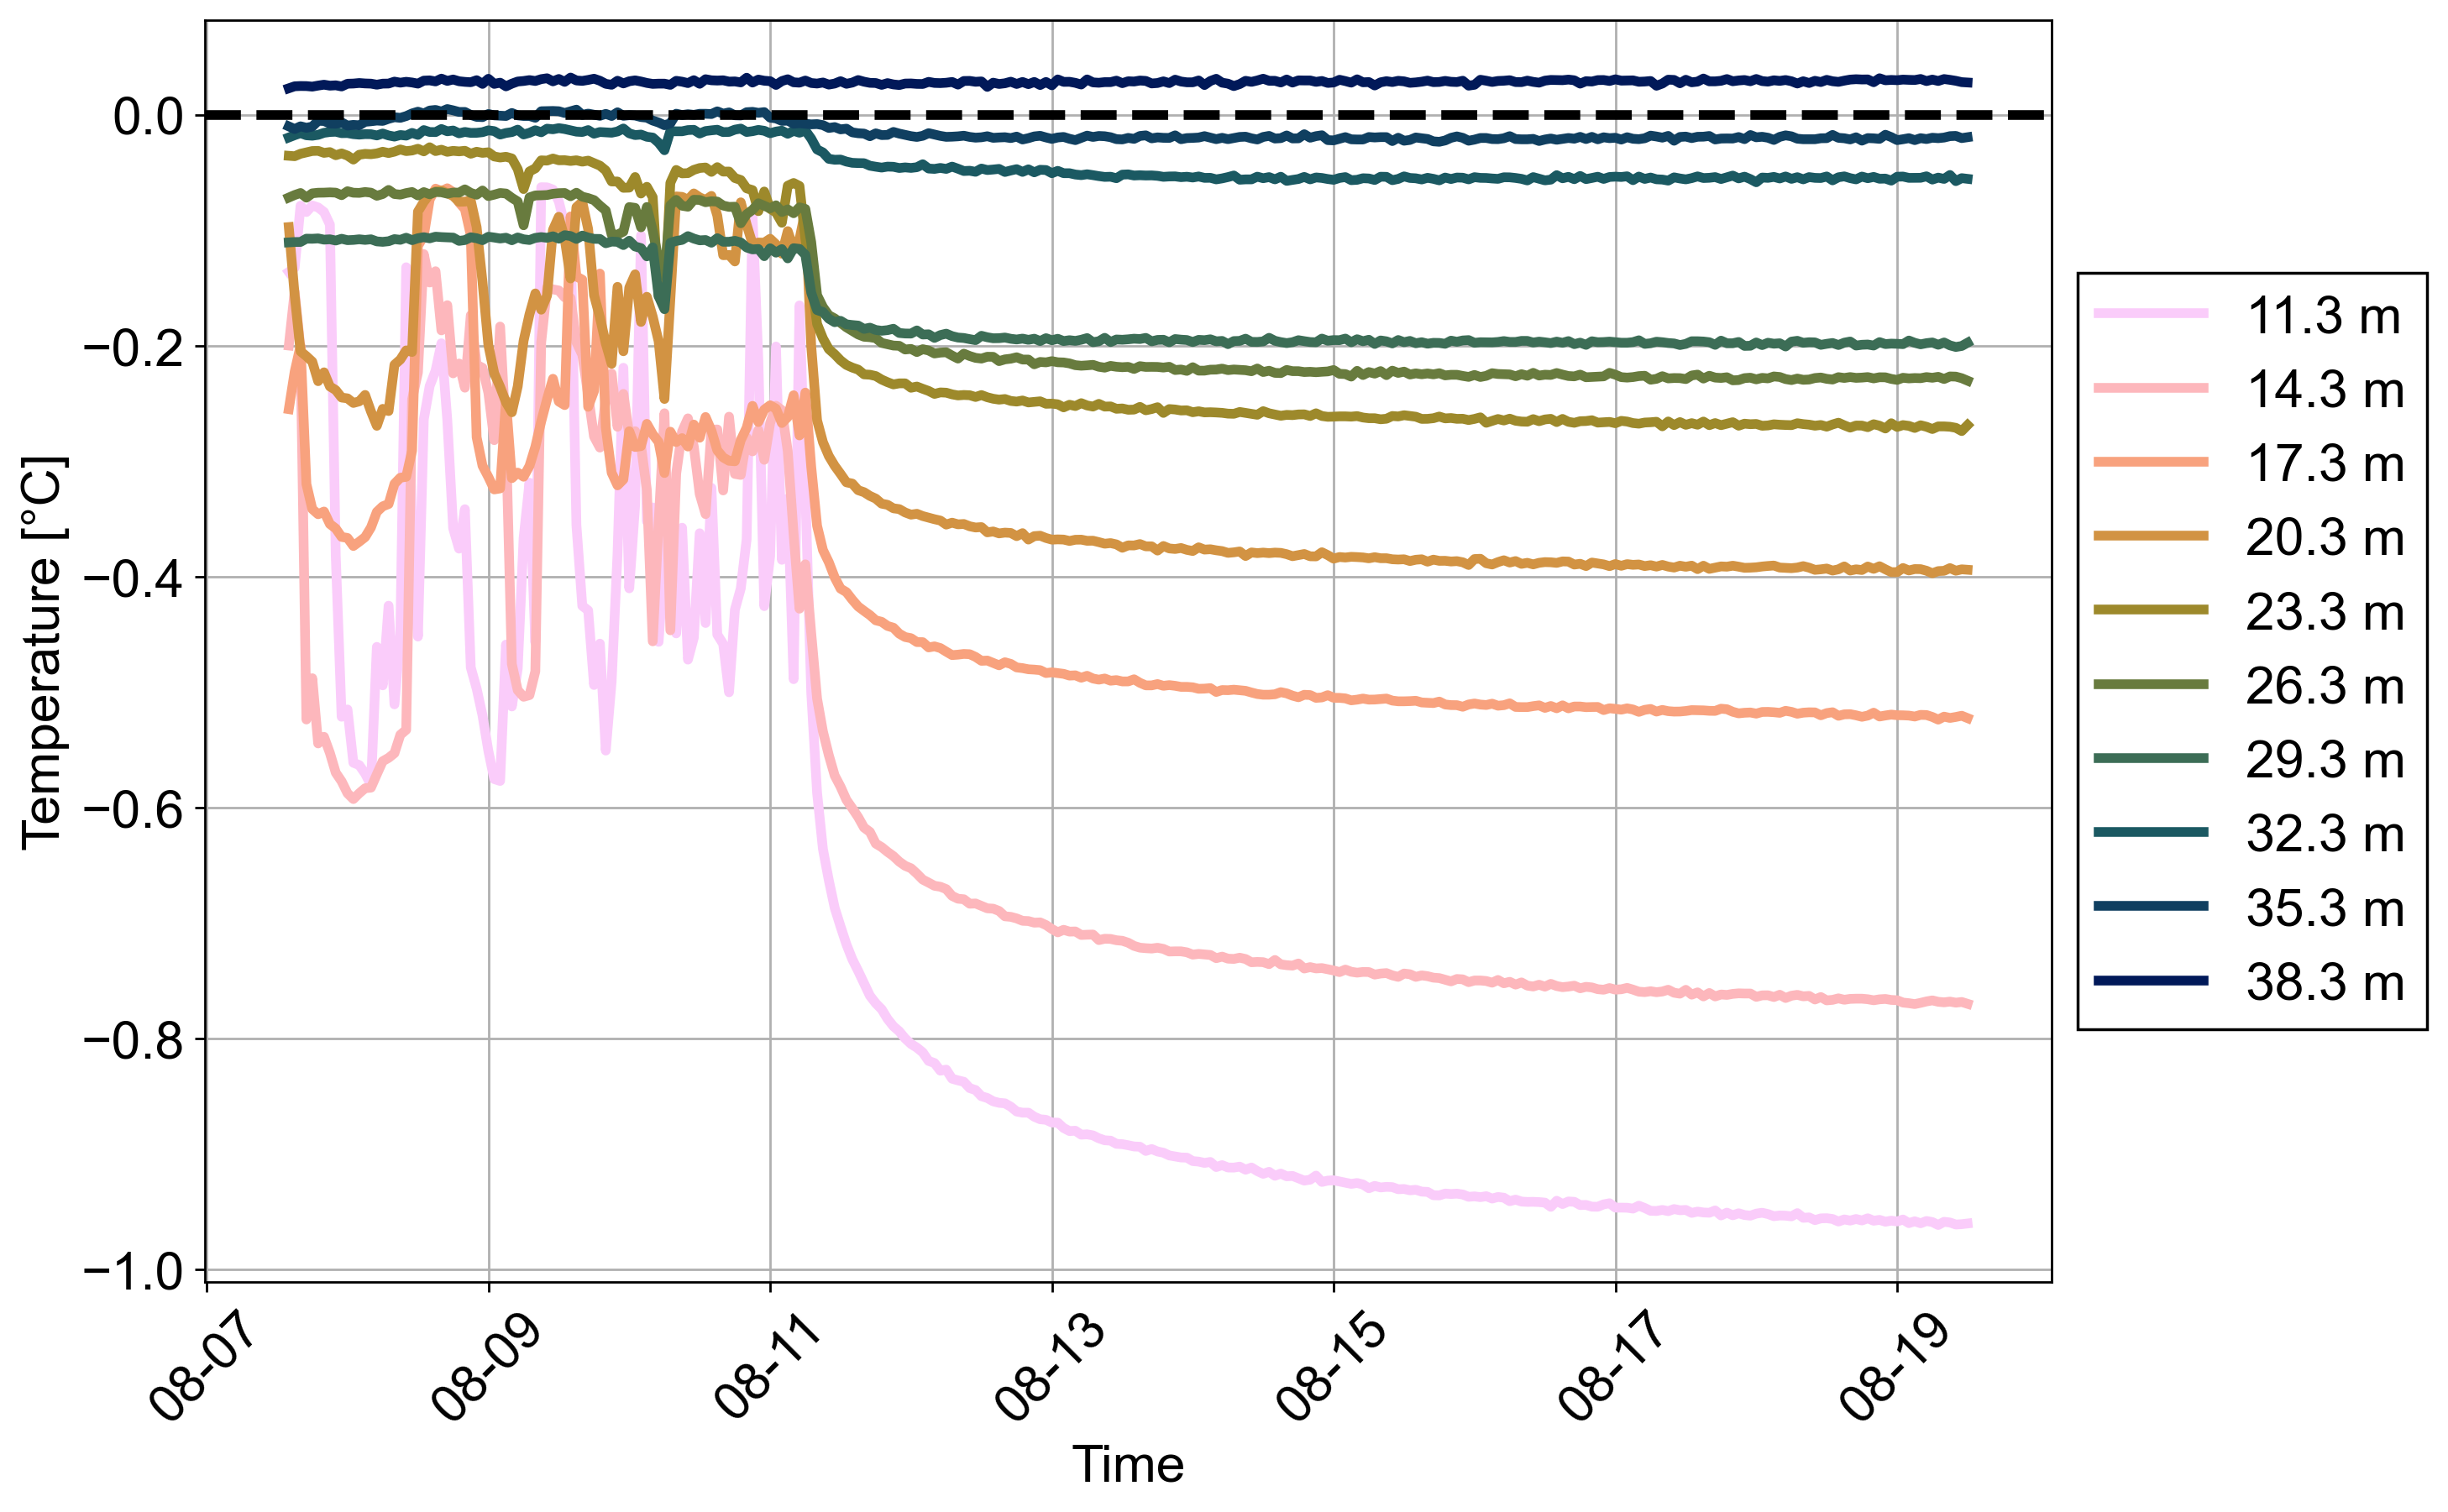

In [10]:
CH1.plot_full_geoprecision_chain('07.08.2025 13:30:00','19.08.2025 13:00:00', A55201_offsets, output_dir + "CH1_full_chain.png", depth_file=depth_ch1)

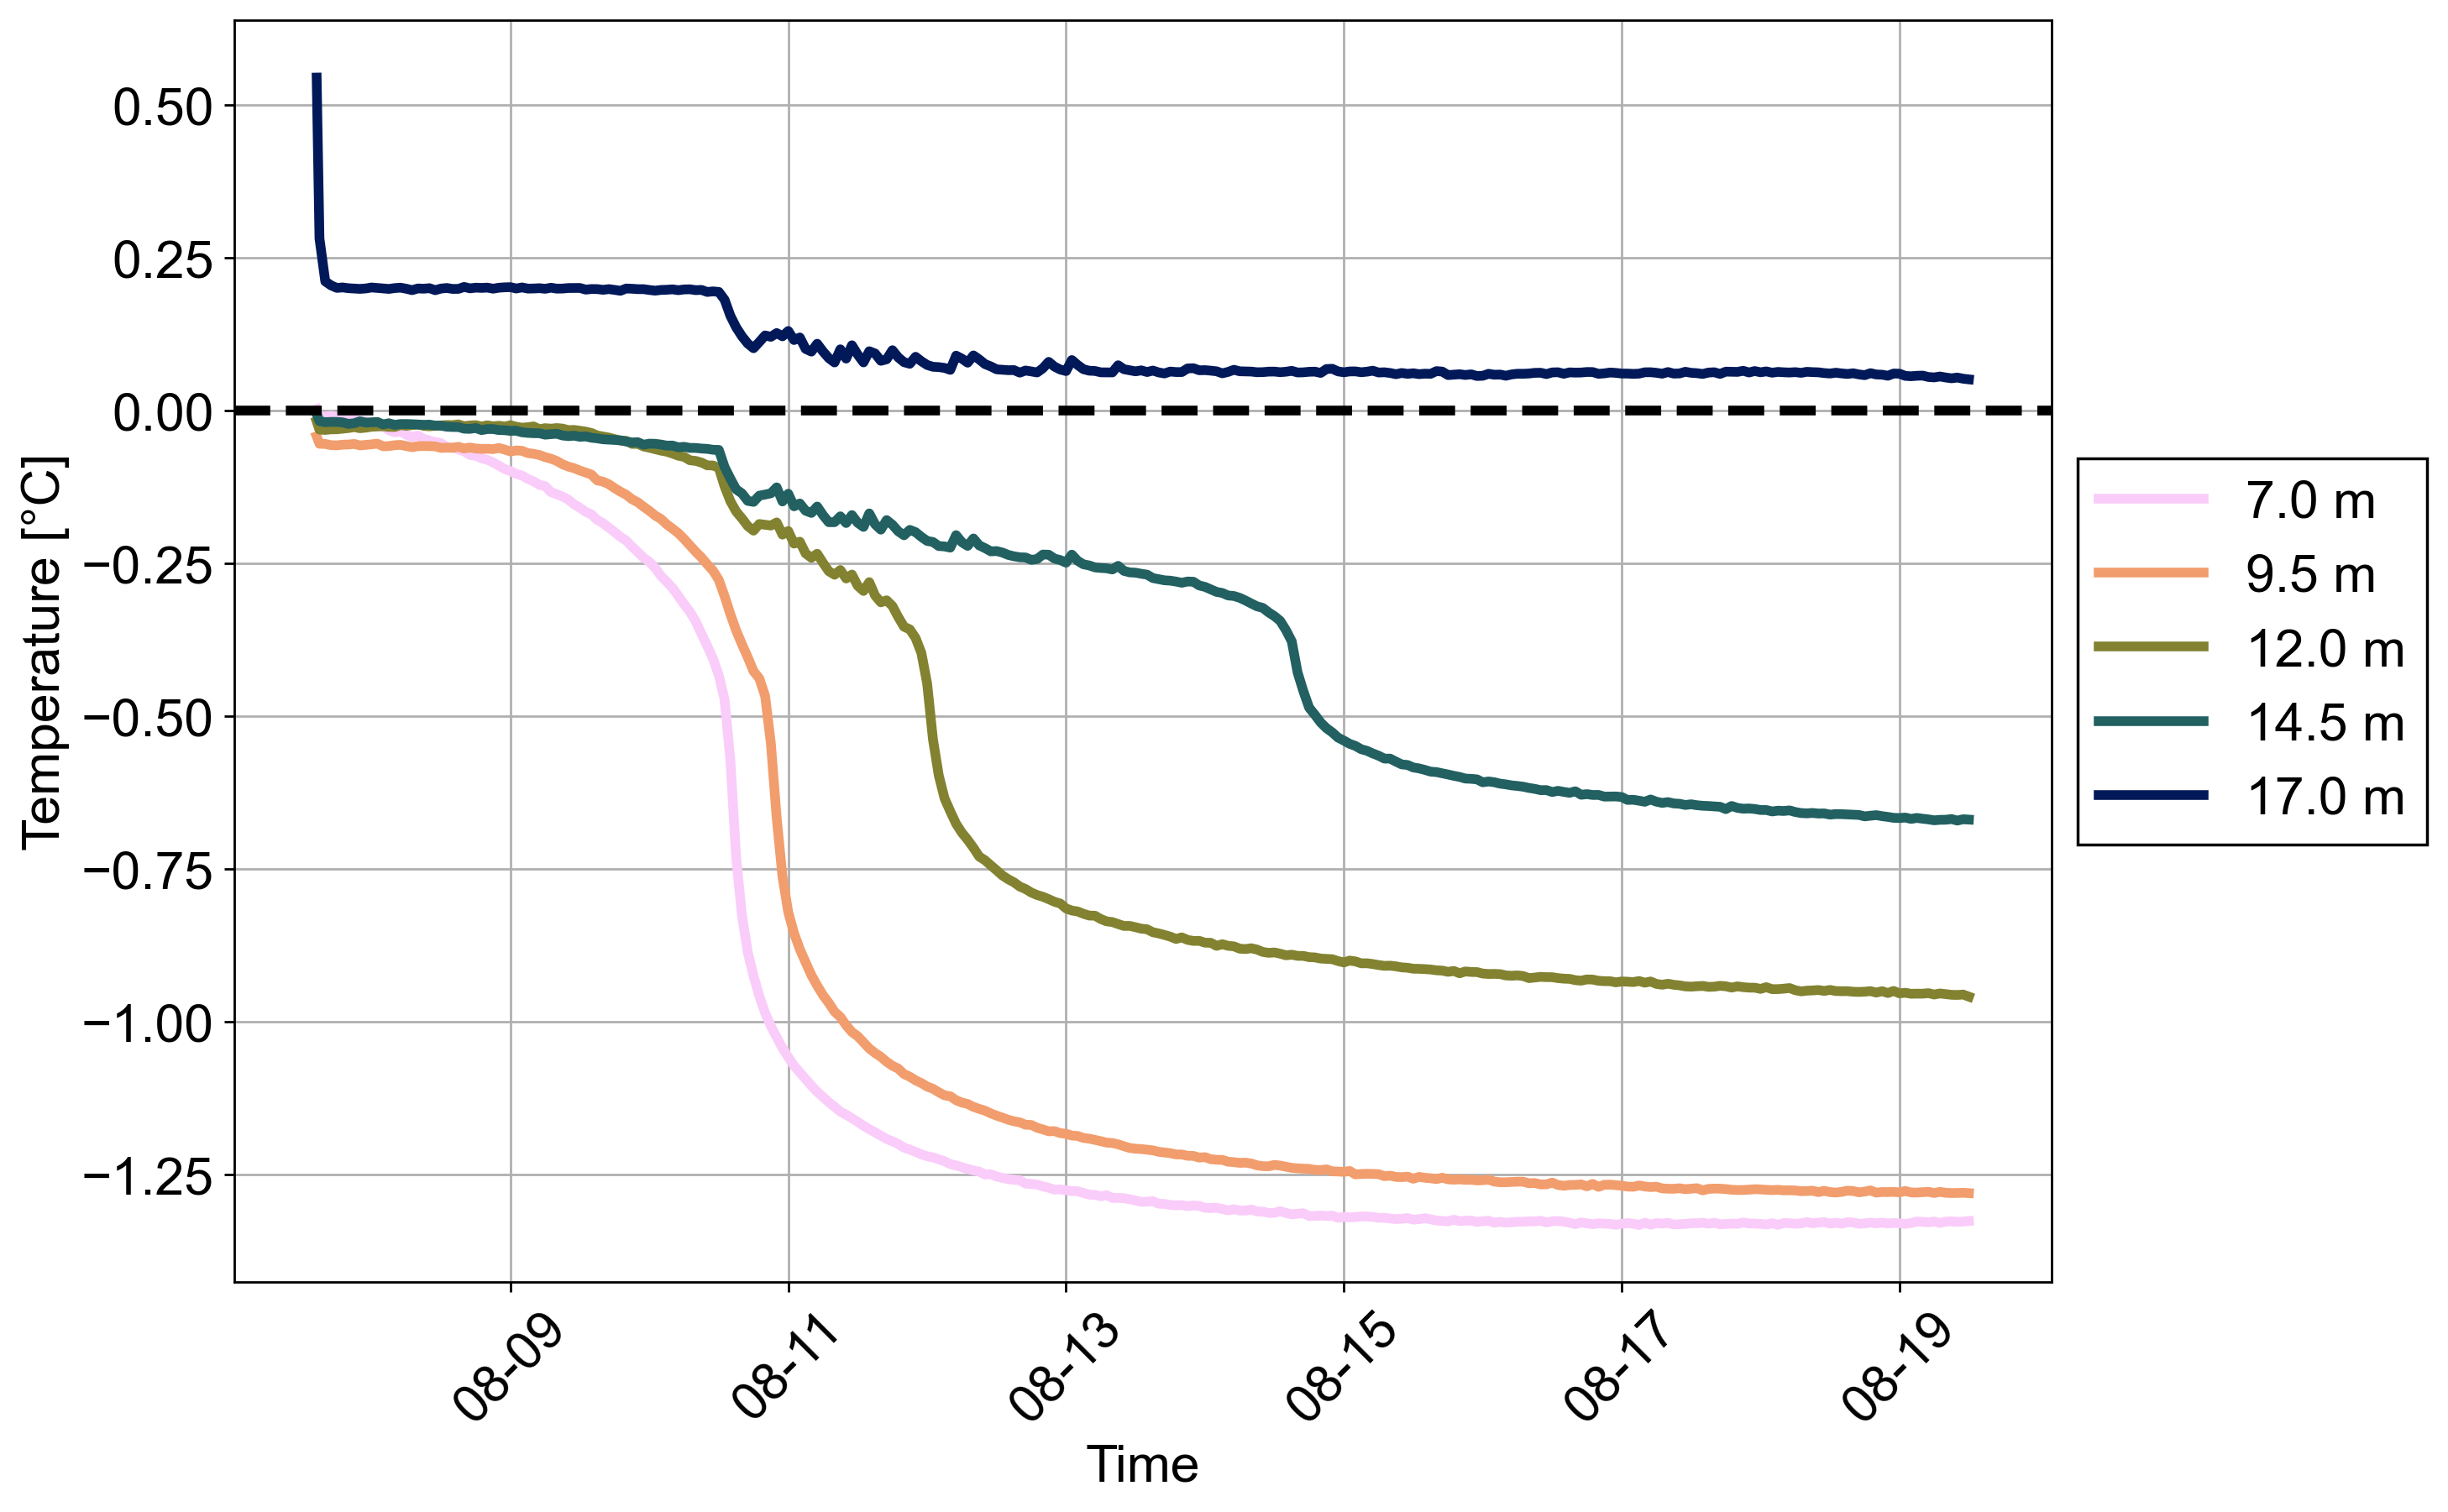

In [11]:
CH2.plot_full_geoprecision_chain('07.08.2025 13:30:00','19.08.2025 13:00:00', A55202_offsets, output_dir + "CH2_full_chain.png", depth_file=depth_ch2)

### Profiles

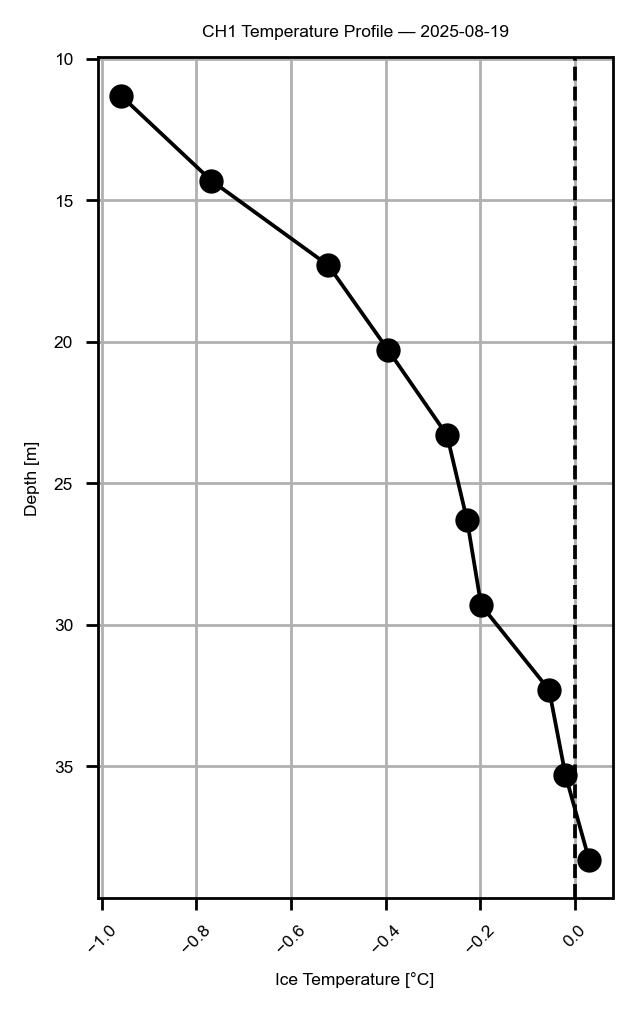

In [12]:
CH1.plot_temperature_profile('19.08.2025', depth_file=depth_ch1, offsets=A55201_offsets, savepath=output_dir + "CH1_temperature_profile.png", title="CH1 Temperature Profile")


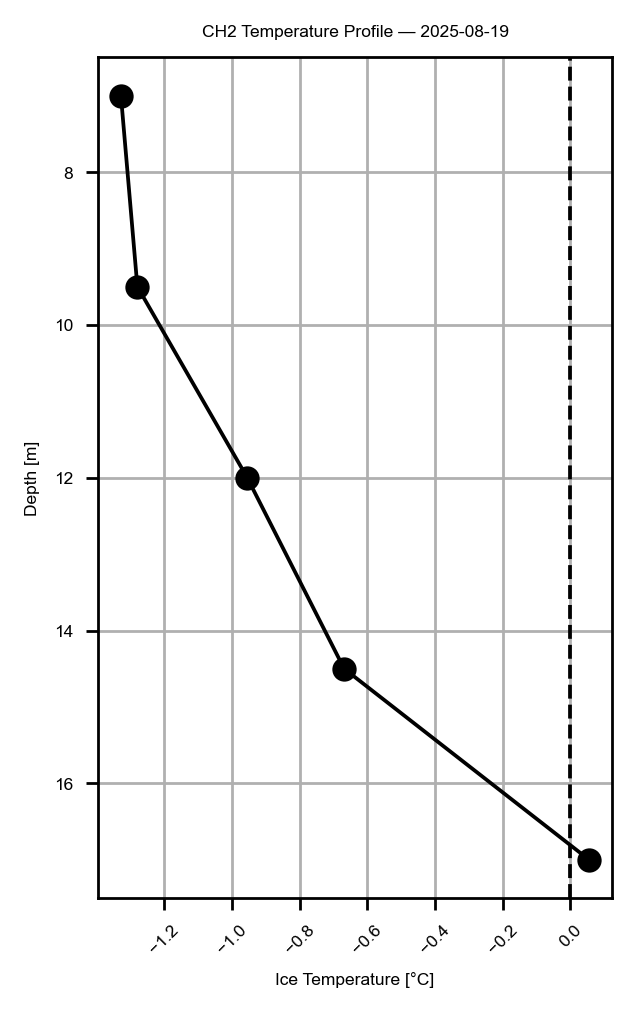

In [13]:
CH2.plot_temperature_profile('19.08.2025', depth_file=depth_ch2, offsets=A55202_offsets, savepath=output_dir + "CH2_temperature_profile.png", title="CH2 Temperature Profile")


In [14]:
# List containing file paths for all thermistor chain data per glacier
ch_file_paths = [A55201_dir, A55202_dir]  # Chessjengletscher
CH = ThermistorDataPlotter(ch_file_paths, delimiter=',')

In [15]:
depth_ch1

'/Users/janoschbeer/Library/Mobile Documents/com~apple~CloudDocs/PhD/data/fieldwork_data/THERMAP_2024_2025/icetemperature_data/thermistor_chains/temperature_data/../../thermistor_settings/thermistor_settings_ch1.csv'

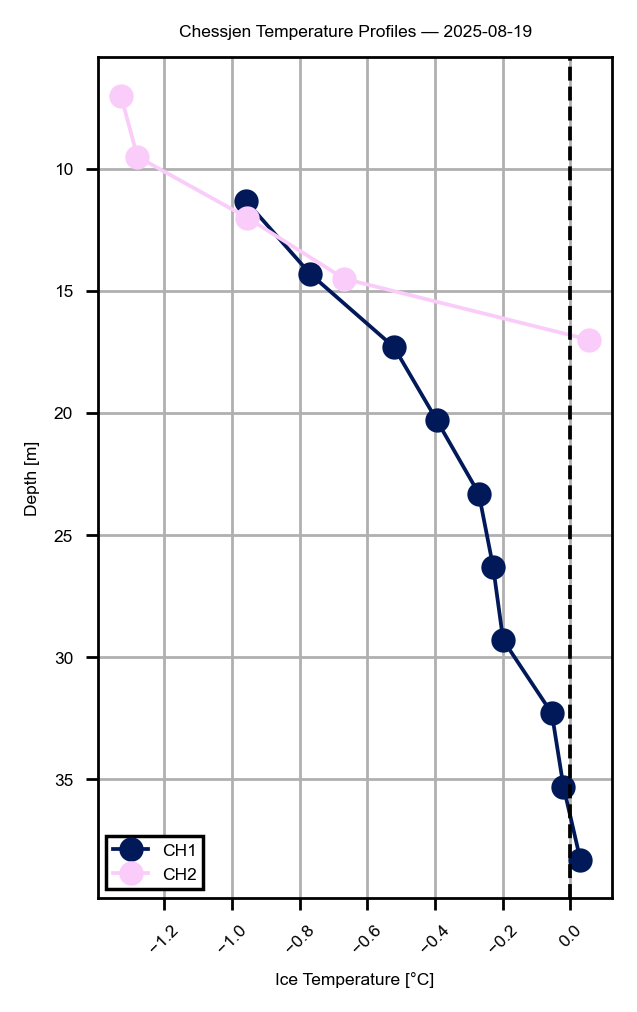

In [16]:
CH.plot_multiple_temperature_profiles(
    snapshot_time='19.08.2025',
    offsets_list=[A55201_offsets, A55202_offsets],
    depth_files=[depth_ch1, depth_ch2],
    labels=['CH1', 'CH2'],
    savepath=output_dir + "CH_profiles.png",
    title="Chessjen Temperature Profiles"
)

### Incorporate the Tynitag thermistor data into the profiles

In [17]:
# Tynitag thermistor ice temperature dir
tt_icetemp_dir = root_dir + 'NTC_tynitag/temperature_data/2024/'

# set glacier specific dirs
tt_CH_dirs  = [tt_icetemp_dir + 'BH7_chessjen_20240809_20240929.csv', tt_icetemp_dir + 'BH8_chessjen_20240809_20240929.csv']

# set path to depth files
depth_ch5TT_dir = root_dir + 'thermistor_settings/thermistor_settings_CH5TT.csv'
depth_ch6TT_dir = root_dir + 'thermistor_settings/thermistor_settings_CH6TT.csv'

# read depth files
depths_ch5tt = read_tynitag_depth_file(depth_ch5TT_dir)
depths_ch6tt = read_tynitag_depth_file(depth_ch6TT_dir)

# generate tynitag thermistor data object
tt_CH_data = ThermistorData(tt_CH_dirs, delimiter=',')

In [18]:
# read NTC data 
tt_CH_data_list = tt_CH_data.get_multiple_ntc_data() # list of DataFrames, each corresponding to a borehole

# read out specific borehole data
CH5tt_data = tt_CH_data_list[0]
CH6tt_data = tt_CH_data_list[1]

# Daily mean snapshot for 2024-08-19
CH5tt_snapshot = ntc_daily_snapshot(CH5tt_data, '20240819')
CH6tt_snapshot = ntc_daily_snapshot(CH6tt_data, '20240819')

# read offsets
tynitag_offsets = pd.read_csv(tt_icetemp_dir + '../../calibration_data/all_logger_offsets.csv')

# get data offsets for CH5 & CH6
CH5tt_offsets = tynitag_offsets[tynitag_offsets['Logger'] == 7]
CH6tt_offsets = tynitag_offsets[tynitag_offsets['Logger'] == 8]

In [19]:
CH5tt_data

,Measurement,TIME,Black Probe Temperature,White Probe Temperature
0,1,2024-08-09 10:01:00,8.869,7.741
1,2,2024-08-09 11:01:00,7.438,10.746
2,3,2024-08-09 12:01:00,10.948,15.034
3,4,2024-08-09 13:01:00,5.862,8.749
4,5,2024-08-09 14:01:00,7.157,10.863
...,...,...,...,...
1219,1220,2024-09-29 05:01:00,-0.554,-0.840
1220,1221,2024-09-29 06:01:00,-0.554,-0.840
1221,1222,2024-09-29 07:01:00,-0.554,-0.840
1222,1223,2024-09-29 08:01:00,-0.554,-0.840


### Generate dataframes for tynitag data
- with offsets 
- without offsets

In [20]:
# tynitag data with offsets
combined_ch5tt_with_offsets = combine_tynitag_data(depths_ch5tt, CH5tt_snapshot, CH5tt_offsets)
combined_ch6tt_with_offsets = combine_tynitag_data(depths_ch6tt, CH6tt_snapshot, CH6tt_offsets)

# tynitag data without offsets
combined_ch5tt_without_offsets = combine_tynitag_data(depths_ch5tt, CH5tt_snapshot)
combined_ch6tt_without_offsets = combine_tynitag_data(depths_ch6tt, CH6tt_snapshot)

# combine tynitag data
chtt_combined = [combined_ch5tt_with_offsets, combined_ch6tt_with_offsets]

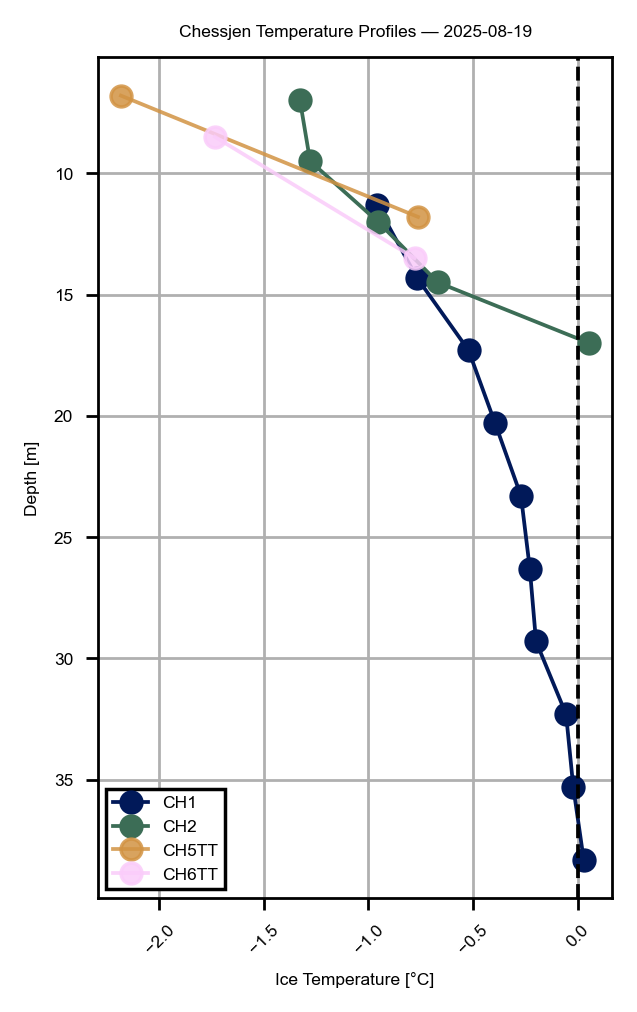

In [21]:
CH.plot_multiple_temperature_profiles(
    snapshot_time='19.08.2025',
    offsets_list=[A55201_offsets, A55202_offsets],
    depth_files=[depth_ch1, depth_ch2],
    labels=['CH1', 'CH2', 'CH5TT', 'CH6TT'],
    ntc_data_list=chtt_combined,
    savepath=output_dir + "CH_profiles.png",
    title="Chessjen Temperature Profiles"
)